In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
import joblib
from scipy.stats import wasserstein_distance

selection = "ATLAS"
sample_path = f"Models_Extrapolation_{selection}_ver2/samples"
dataset_path = f"Final_Dataset_{selection}"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
N_ENSEMBLE = 10
scaler = joblib.load(SCALER_PATH)

NOM_WEIGHT_COL = "final_weight"
RW_WEIGHT_COL = "rw_median_weights"
GEN_WEIGHT_COL = "total_weight"

context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
data_cr_events = pd.read_parquet(f"{dataset_path}/CR_Dataset_Splits/DATA_events_test.parquet")

# Load Reweight Events
mc_cr_reweight_events = pd.read_parquet(f"{sample_path}/MC_CR_reweighted.parquet")
nominal_w = mc_cr_reweight_events["final_weight"].values
rw_ensemble_weights = [mc_cr_reweight_events[f"reweight_weights_ens{i}"].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
mc_cr_reweight_events["rw_median_weights"] = nominal_w * rw_median
# Load Generate Events

mc_cr_generate_dfs = []
for i in range(N_ENSEMBLE):
    df = pd.read_parquet(f"{sample_path}/MC_CR_Generate_ens{i}.parquet")
    df['total_weight'] = df['total_weight']/10

    mc_cr_generate_dfs.append(df)

df_mc_gen_cr = pd.concat(mc_cr_generate_dfs, ignore_index=True)


print(f"Loaded {len(data_cr_events)} Data events")
print(f"Loaded {len(mc_cr_reweight_events)} MC reweight events")
print(f"Loaded {len(df_mc_gen_cr)/10} MC generate events")
w1_cr_results = {
    "nom": {},
    "rw": {},
    "gen": {}
}

Loaded 21983 Data events
Loaded 84161 MC reweight events
Loaded 84161.0 MC generate events


In [3]:
def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def check_negative_weight_stats(weights, dataset_name="Dataset"):
    """
    Analyzes the statistics of negative weights in a dataset and calculates
    the physical impact (yield inflation) of common workarounds.
    """
    total_events = len(weights)
    if total_events == 0:
        print(f"Dataset {dataset_name} is empty.")
        return

    # Basic masking and counting
    neg_mask = weights < 0
    neg_events = np.sum(neg_mask)
    pos_events = total_events - neg_events
    pct_events_neg = (neg_events / total_events) * 100
    
    # Calculate yields (sum of weights)
    true_yield = np.sum(weights)
    sum_pos = np.sum(weights[~neg_mask])
    sum_neg = np.sum(weights[neg_mask])
    
    # Calculate workaround impacts
    yield_abs = np.sum(np.abs(weights))
    yield_ignored = sum_pos
    
    # Percentage shifts (normalized against true physical yield)
    shift_abs = ((yield_abs - true_yield) / np.abs(true_yield)) * 100 if true_yield != 0 else 0
    shift_ignored = ((yield_ignored - true_yield) / np.abs(true_yield)) * 100 if true_yield != 0 else 0

    # Print Report
    print(f"=== Negative Weight Report: {dataset_name} ===")
    print(f"Total Events:           {total_events:,}")
    print(f"Negative Events:        {neg_events:,} ({pct_events_neg:.2f}% of dataset)")
    print(f"Positive Events:        {pos_events:,} ({(100 - pct_events_neg):.2f}% of dataset)")
    print("-" * 46)
    print(f"True Physical Yield:    {true_yield:.4f}")
    print(f"Sum of Positive Weights:{sum_pos:.4f}")
    print(f"Sum of Negative Weights:{sum_neg:.4f}")
    print("-" * 46)
    print("Impact of Workarounds on Physical Yield:")
    print(f" 1. ABSOLUTE VALUE: Yield becomes {yield_abs:.4f} (Inflation: +{shift_abs:.2f}%)")
    print(f" 2. IGNORE NEGATIVES: Yield becomes {yield_ignored:.4f} (Inflation: +{shift_ignored:.2f}%)")
    print("===============================================\n")


In [4]:
def check_unphysical(df, name):
    print('='*20, f"Checking {name} for unphysical events", '='*20)
    print("Events with Missing Energy less than 0:", (df['met_recalc_pt'] < 0).sum() + (df['met_recalc_pt'] > 13_000).sum())
    print("Events with HT less than 0:", (df['ht'] < 0).sum() + (df['ht'] > 13_000).sum())
    print("Events with mjj less than 0:", (df['mjj'] < 0).sum() + (df['mjj'] > 13_000).sum())
    for i in ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']:
        print(f"Events with unphysical N-subjettiness ratio {i}:", ((df[i] < 0).sum() + (df[i] > 1).sum()))

def filter_and_renormalize(df, weight_col=None, name="GENERATE"):
    """
    Removes unphysical events from a DataFrame and renormalizes the weights 
    to preserve the total expected yield.
    """
    print('='*20, f"Filtering {name}", '='*20)
    
    # 1. Store the original total yield (sum of weights)

    original_yield = df[weight_col].sum()
    
    # 2. Build a boolean mask where True means the event is physically valid
    mask = (df['met_recalc_pt'] >= 0) & (df['met_recalc_pt'] <= 13_000) &\
           (df['ht'] >= 0) & (df['ht'] <= 13_000) & \
           (df['mjj'] >= 0) & (df['mjj'] <= 13_000)
    
    for tau in ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']:
        mask = mask & (df[tau] >= 0) & (df[tau] <= 1)
        
    # 3. Apply the mask to drop unphysical events
    df_clean = df[mask].copy()
    events_dropped = len(df) - len(df_clean)
    drop_percentage = (events_dropped / len(df)) * 100
    
    print(f"Total events generated: {len(df)}")
    print(f"Events dropped: {events_dropped} ({drop_percentage:.2f}%)")
    
    # 4. Renormalize the weights of the surviving events

    new_yield_before_scaling = df_clean[weight_col].sum()
    
    # Scale factor = Original Yield / Yield of surviving events
    scale_factor = original_yield / new_yield_before_scaling
    df_clean[weight_col] = df_clean[weight_col] * scale_factor
    
    print(f"Original background yield: {original_yield:.2f}")
    print(f"Yield after cuts (before scaling): {new_yield_before_scaling:.2f}")
    print(f"Applied scale factor: {scale_factor:.4f}")
    print(f"Final normalized yield: {df_clean[weight_col].sum():.2f}")
        
    return df_clean

def signed_wasserstein_distance(u_values, v_values, u_weights, v_weights):
    """
    Computes the 1D Wasserstein distance allowing for negative weights.
    """
    # 1. Sort the values and their corresponding weights
    u_sorter = np.argsort(u_values)
    v_sorter = np.argsort(v_values)
    
    u_val_sorted = np.asarray(u_values)[u_sorter]
    v_val_sorted = np.asarray(v_values)[v_sorter]
    u_wt_sorted = np.asarray(u_weights)[u_sorter]
    v_wt_sorted = np.asarray(v_weights)[v_sorter]

    # 2. Combine all unique values to create the integration grid
    all_values = np.concatenate((u_val_sorted, v_val_sorted))
    all_values.sort(kind='mergesort')

    # 3. Compute deltas (dx for the integral)
    deltas = np.diff(all_values)

    # 4. Find the positions to evaluate the CDFs
    u_cdf_indices = np.searchsorted(u_val_sorted, all_values[:-1], side='right')
    v_cdf_indices = np.searchsorted(v_val_sorted, all_values[:-1], side='right')

    # 5. Compute the empirical CDFs (normalized by the total sum of weights)
    u_cumweights = np.concatenate(([0], np.cumsum(u_wt_sorted)))
    v_cumweights = np.concatenate(([0], np.cumsum(v_wt_sorted)))

    # Prevent division by zero if weights sum perfectly to 0
    u_total = u_cumweights[-1]
    v_total = v_cumweights[-1]
    if u_total == 0 or v_total == 0:
        raise ValueError("Total sum of weights cannot be zero.")

    u_cdf = u_cumweights[u_cdf_indices] / u_total
    v_cdf = v_cumweights[v_cdf_indices] / v_total

    # 6. Compute the integral of the absolute difference
    return np.sum(np.abs(u_cdf - v_cdf) * deltas)


In [5]:
df_data_cr_unscaled = transform(data_cr_events, scale=False)
df_mc_rw_cr_unscaled = transform(mc_cr_reweight_events, scale=False)
df_mc_gen_cr_unscaled = transform(df_mc_gen_cr, scale=False)

check_unphysical(df_data_cr_unscaled, "DATA")
check_unphysical(df_mc_rw_cr_unscaled, "REWEIGHT")
check_unphysical(df_mc_gen_cr_unscaled, "GENERATE")

df_mc_rw_cr_cleaned = filter_and_renormalize(df_mc_rw_cr_unscaled, weight_col=RW_WEIGHT_COL, name="REWEIGHT")
df_mc_gen_cr_cleaned = filter_and_renormalize(df_mc_gen_cr_unscaled, weight_col=GEN_WEIGHT_COL, name="GENERATE")

df_mc_rw_cwola = transform(df_mc_rw_cr_cleaned, scale=True)
df_mc_gen_cwola = transform(df_mc_gen_cr_cleaned, scale=True)


==================== Checking DATA for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events with mjj less than 0: 0
Events with unphysical N-subjettiness ratio ljet1_tau21: 0
Events with unphysical N-subjettiness ratio ljet1_tau32: 0
Events with unphysical N-subjettiness ratio ljet2_tau21: 0
Events with unphysical N-subjettiness ratio ljet2_tau32: 0
==================== Checking REWEIGHT for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events with mjj less than 0: 0
Events with unphysical N-subjettiness ratio ljet1_tau21: 0
Events with unphysical N-subjettiness ratio ljet1_tau32: 0
Events with unphysical N-subjettiness ratio ljet2_tau21: 0
Events with unphysical N-subjettiness ratio ljet2_tau32: 0
==================== Checking GENERATE for unphysical events ====================
Events with Missing Energy less than 0: 0
Events with HT less than 0: 0
Events w

Data events shape: (21983, 10)
Reweighted events shape: (84161, 23)
Generated events shapes: (832095, 9)
 == Check W1 ==
Data W1: 0.0


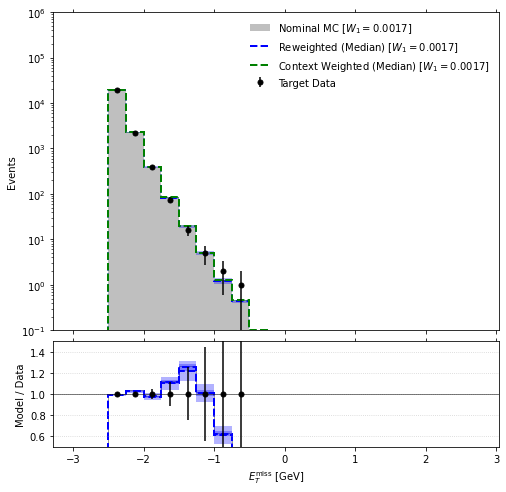

 == Check W1 ==
Data W1: 0.0


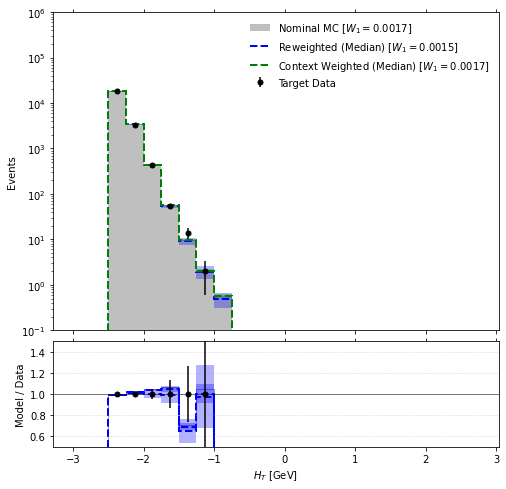

 == Check W1 ==
Data W1: 0.0


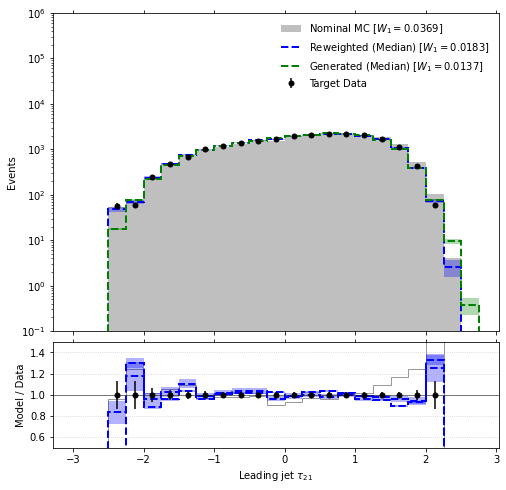

 == Check W1 ==
Data W1: 0.0


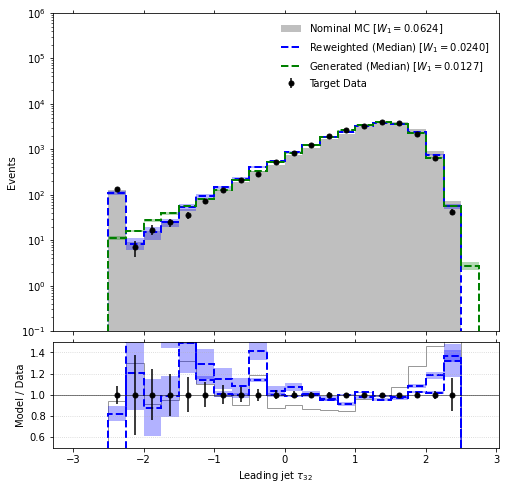

 == Check W1 ==
Data W1: 0.0


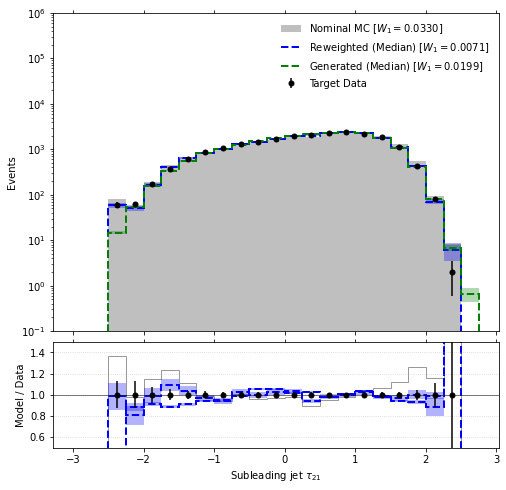

 == Check W1 ==
Data W1: 0.0


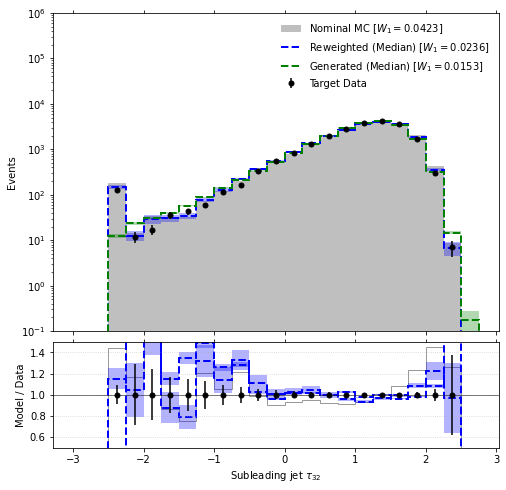

 == Check W1 ==
Data W1: 0.0


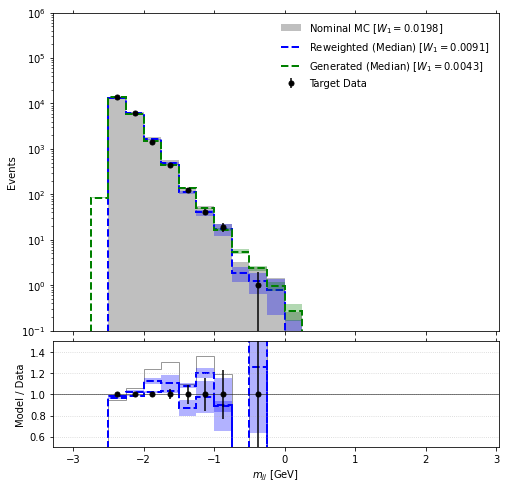

In [6]:
def plot_context_events(data_events, reweight_events, generate_events):
    print(f"Data events shape: {data_events.shape}")
    print(f"Reweighted events shape: {reweight_events.shape}")
    print(f"Generated events shapes: {generate_events.shape}")
    
    bins = np.arange(-3.0, 3.0, 0.25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]',
        'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]',
        'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for var in context_vars + features_vars:
        # Create a figure with two vertically stacked panels
        fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(8, 8), 
            gridspec_kw={'height_ratios': [3, 1]}, 
            sharex=True
        )
        
        # Remove horizontal space between axes
        fig.subplots_adjust(hspace=0.05)

        # ==========================================
        # TARGET DATA (Calculated once for both panels)
        # ==========================================
        data_arr = data_events[var].to_numpy()
        w_data = np.ones(len(data_events))
        counts_data, _ = np.histogram(data_arr, bins=bins)
        data_errors = np.sqrt(counts_data)
        std_data = np.std(data_arr)
        # w1_data = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=counts_data)/std_data
        w1_data = signed_wasserstein_distance(data_events[var], data_events[var], w_data, w_data)

        print(" == Check W1 ==")
        print("Data W1:", w1_data)
        
        # Top panel: Data
        ax1.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Target Data', zorder=10, capsize=0, markersize=5)

        # Bottom panel: Data reference at 1.0
        # Safe division to get fractional errors for the ratio plot
        valid = counts_data > 0
        data_ratio_err = np.zeros_like(counts_data, dtype=float)
        data_ratio_err[valid] = data_errors[valid] / counts_data[valid]
        
        ax2.errorbar(bin_centers[valid], np.ones_like(counts_data[valid]), yerr=data_ratio_err[valid], fmt='ko', zorder=10, capsize=0, markersize=5)
        ax2.axhline(1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # ==========================================
        # NOMINAL MC
        # ==========================================
        mc_nom = reweight_events[var].to_numpy()
        w_nom = reweight_events[NOM_WEIGHT_COL].to_numpy()
        
        counts_nom, _ = np.histogram(mc_nom, bins=bins, weights=w_nom)
        # w1_nom = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=counts_nom)/std_data
        w1_nom = signed_wasserstein_distance(data_arr, mc_nom, w_data, w_nom)

        ax1.stairs(counts_nom, bins, fill=True, color="grey", alpha=0.5, label=f'Nominal MC [$W_1 = {w1_nom:.4f}$]')
        
        # Nominal ratio
        ratio_nom = np.divide(counts_nom, counts_data, out=np.full_like(counts_nom, np.nan, dtype=float), where=valid)
        ax2.stairs(ratio_nom, bins, color="grey", alpha=0.8)

        # ==========================================
        # REWEIGHT EVENTS
        # ==========================================
        mc_rw = reweight_events[var].to_numpy()
        w_rw = reweight_events[RW_WEIGHT_COL].values

        rw_binned, _ = np.histogram(mc_rw, bins=bins, weights=w_rw)
        rw_variance, _ = np.histogram(mc_rw, bins=bins, weights=w_rw**2)
        rw_error = np.sqrt(rw_variance)

        rw_lower = rw_binned - rw_error
        rw_upper = rw_binned + rw_error

        # w1_rw = wasserstein_distance(bin_centers, bin_centers, u_weights=counts_data, v_weights=rw_median)/std_data
        w1_rw = signed_wasserstein_distance(data_arr, mc_rw, w_data, w_rw)
        # Top panel
        ax1.stairs(rw_binned, bins, color="blue", linewidth=2, linestyle='--', label=f'Reweighted (Median) [$W_1 = {w1_rw:.4f}$]')
        ax1.stairs(rw_upper, bins, baseline=rw_lower, fill=True, color='blue', alpha=0.3)

        # Bottom panel
        rw_ratio = np.divide(rw_binned, counts_data, out=np.full_like(rw_binned, np.nan, dtype=float), where=valid)
        rw_ratio_low = np.divide(rw_lower, counts_data, out=np.full_like(rw_lower, np.nan, dtype=float), where=valid)
        rw_ratio_up = np.divide(rw_upper, counts_data, out=np.full_like(rw_upper, np.nan, dtype=float), where=valid)
        
        ax2.stairs(rw_ratio, bins, color="blue", linewidth=2, linestyle='--')
        ax2.stairs(rw_ratio_up, bins, baseline=rw_ratio_low, fill=True, color='blue', alpha=0.3)

        # ==========================================
        # GENERATE EVENTS
        # ==========================================

        mc_gen = generate_events[var].to_numpy()
        w_gen = generate_events[GEN_WEIGHT_COL].values
        gen_binned, _ = np.histogram(mc_gen, bins=bins, weights=w_gen)

        gen_variance, _ = np.histogram(mc_gen, bins=bins, weights=w_gen**2)
        gen_err = np.sqrt(gen_variance)

        gen_lower = gen_binned - gen_err
        gen_upper = gen_binned + gen_err

        w1_cw = signed_wasserstein_distance(data_arr, mc_gen, w_data, w_gen)
        # Top panel
        if var in context_vars:
            label_gen = 'Context Weighted (Median)'
        else:
            label_gen = 'Generated (Median)'

        ax1.stairs(gen_binned, bins, color='green', linewidth=2, linestyle = '--', label = f"{label_gen} [$W_1 = {w1_cw:.4f}$]")
        ax1.stairs(gen_upper, bins, baseline=gen_lower, fill=True, color ='green', alpha = 0.3)

        # Bottom panel
        gen_ratio = np.divide(gen_binned, counts_data, out=np.full_like(gen_binned, np.nan, dtype=float), where=valid)
        gen_ratio_low = np.divide(gen_lower, counts_data, out=np.full_like(gen_lower, np.nan, dtype=float), where=valid)
        gen_ratio_up = np.divide(gen_upper, counts_data, out=np.full_like(gen_upper, np.nan, dtype=float), where=valid)

        ax2.stairs(gen_ratio, bins, color = 'blue', linewidth=2, linestyle='--')
        ax2.stairs(gen_ratio_up, bins, baseline=gen_ratio_low, fill=True, color='blue', alpha=0.3)
        # ==========================================
        # PLOT FORMATTING
        # ==========================================
        # Top Panel
        ax1.set_yscale('log')
        ax1.set_ylim(0.1, 1e6)
        ax1.set_ylabel('Events')
        ax1.legend(frameon=False)
        ax1.tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=False)

        # Bottom Panel (Ratio)
        ax2.set_ylabel('Model / Data')
        # Adjust these limits based on how wild your ratios get. 0.5 to 1.5 is standard.
        ax2.set_ylim(0.5, 1.5) 
        ax2.set_xlabel(pretty_labels.get(var, var))
        ax2.tick_params(axis='x', which='both', bottom=True, top=True)
        ax2.grid(True, axis='y', linestyle=':', alpha=0.6)

        w1_cr_results['nom'][var] = w1_nom
        w1_cr_results['rw'][var] = w1_rw
        w1_cr_results['gen'][var] = w1_cw

        plt.show()
plot_context_events(data_cr_events, df_mc_rw_cwola, df_mc_gen_cwola)

In [7]:
df_w1_cr_results = pd.DataFrame.from_dict(w1_cr_results, orient='index')
df_w1_cr_results.to_csv("Results/w1_cr_results.csv")

In [8]:
# Run Classifier Ensemble
import os
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

helpers_path = os.path.abspath('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier


def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, classifier_runs=20):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    n_features = set_1.shape[1]
    
    # ---------- Logging ----------
    print(f"\nWorking on {code}...")
    print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        print(f"\nClassifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
        
        # 2 & 4. SPLIT INSIDE THE LOOP (Flat 20% Test Size)
        # random_state=i ensures a unique train/test combination for each of the 20 runs.
        trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(
            set_1, w_1, test_size=0.2, random_state=i
        )
        trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(
            set_2, w_2, test_size=0.2, random_state=i
        )

        # 1. APPLY WEIGHTS AS IS
        # No scaling/normalization applied here to preserve Anomaly Detection physics.
        input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
        input_y_train = np.concatenate([
            np.zeros(trainset_1.shape[0]),
            np.ones(trainset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw training weights directly
        input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

        input_x_test = np.concatenate([testset_1, testset_2], axis=0)
        input_y_test = np.concatenate([
            np.zeros(testset_1.shape[0]),
            np.ones(testset_2.shape[0])
        ]).reshape(-1, 1)
        
        # Concatenate raw testing weights directly
        combined_test_weights = np.concatenate([wtest_1, wtest_2])

        if i == 0:
            print(f"      Train shapes: X:{input_x_train.shape}, y:{input_y_train.shape}, w:{input_w_train.shape}")
            print(f"      Test shapes: X:{input_x_test.shape}, y:{input_y_test.shape}")
                
        # 3. NO SCALING APPLIED (scale_data=False)
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        if i == 0: print("Using device:", NN.device)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=i, outdir=save_dir)

        # 4. EVALUATION
        scores = NN.evaluation(input_x_test)
        auc = roc_auc_score(input_y_test, scores, sample_weight=np.abs(combined_test_weights))

        aucs_list.append(auc)
        
        print(f"   --> AUC: {auc:.4f}")
    
    # ---------- Save results ----------
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\n--- Summary for", code, "---")
    print(f"Median AUC:       {np.median(aucs_list):.4f}")
    print(f"16th percentile:  {np.percentile(aucs_list, 16):.4f}")
    print(f"84th percentile:  {np.percentile(aucs_list, 84):.4f}")
    print("Done.\n")

In [9]:
device = torch.device("cpu")
print("Device:", device)
config_path = "configs"
eval_dir = f"Eval_CWoLa_CR_{selection}_ver2"
os.makedirs(eval_dir, exist_ok=True)
with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

Device: cpu


In [10]:
features_data = data_cr_events[features_vars].values
w_data = np.ones(len(features_data))

features_nom = df_mc_rw_cwola[features_vars].values
w_nom = df_mc_rw_cwola[NOM_WEIGHT_COL].values

features_rw = df_mc_rw_cwola[features_vars].values
w_rw = df_mc_rw_cwola[RW_WEIGHT_COL].values

features_gen = df_mc_gen_cwola[features_vars].values
w_gen = df_mc_gen_cwola[GEN_WEIGHT_COL].values

In [11]:
# Save CR events
cr_datasets_paths = os.path.join(eval_dir, "cr_datasets")
os.makedirs(cr_datasets_paths, exist_ok=True)

data_cr_events.to_parquet(f"{cr_datasets_paths}/DATA_CR_events.parquet", index=False)
df_mc_rw_cwola.to_parquet(f"{cr_datasets_paths}/MC_CR_RW_events.parquet", index=False)
df_mc_gen_cwola.to_parquet(f"{cr_datasets_paths}/MC_CR_GEN_events.parquet", index=False)

In [12]:
check_negative_weight_stats(w_data, dataset_name="DATA")
check_negative_weight_stats(w_nom, dataset_name="Nominal MC")
check_negative_weight_stats(w_rw, dataset_name="Reweighted MC")
check_negative_weight_stats(w_gen, dataset_name="Generated MC")

=== Negative Weight Report: DATA ===
Total Events:           21,983
Negative Events:        0 (0.00% of dataset)
Positive Events:        21,983 (100.00% of dataset)
----------------------------------------------
True Physical Yield:    21983.0000
Sum of Positive Weights:21983.0000
Sum of Negative Weights:0.0000
----------------------------------------------
Impact of Workarounds on Physical Yield:
 1. ABSOLUTE VALUE: Yield becomes 21983.0000 (Inflation: +0.00%)
 2. IGNORE NEGATIVES: Yield becomes 21983.0000 (Inflation: +0.00%)

=== Negative Weight Report: Nominal MC ===
Total Events:           84,161
Negative Events:        5,603 (6.66% of dataset)
Positive Events:        78,558 (93.34% of dataset)
----------------------------------------------
True Physical Yield:    22080.1597
Sum of Positive Weights:22211.6456
Sum of Negative Weights:-131.4859
----------------------------------------------
Impact of Workarounds on Physical Yield:
 1. ABSOLUTE VALUE: Yield becomes 22343.1315 (Inflati

In [13]:
print("CWoLa CR: Data vs Nominal")

run_eval(features_nom, features_data, code=f"Data_vs_Nom_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_nom, w_2=w_data)

CWoLa CR: Data vs Nominal

Working on Data_vs_Nom_ATLAS...
      Total Events - Set 1: 84161, Set 2: 21983

Classifier run 1 of 20.
      Train shapes: X:(84914, 5), y:(84914, 1), w:(84914, 1)
      Test shapes: X:(21230, 5), y:(21230, 1)


Using device: cpu


 14%|=         | 7/50 [04:45<29:13, 40.77s/it]


   --> AUC: 0.5564

Classifier run 2 of 20.


 22%|==        | 11/50 [07:10<25:28, 39.18s/it]


...

   --> AUC: 0.5641

Classifier run 19 of 20.


 24%|==        | 12/50 [07:31<23:49, 37.62s/it]


   --> AUC: 0.5646

Classifier run 20 of 20.


 26%|==>       | 13/50 [08:01<22:51, 37.08s/it]

   --> AUC: 0.5591

--- Summary for Data_vs_Nom_ATLAS ---
Median AUC:       0.5560
16th percentile:  0.5506
84th percentile:  0.5594
Done.



In [14]:
print(f"CWoLa CR: Data vs Reweight (Median of {N_ENSEMBLE} models)")

run_eval(features_rw, features_data, code=f"Data_vs_Reweight_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_rw, w_2=w_data)

CWoLa CR: Data vs Reweight (Median of 10 models)

Working on Data_vs_Reweight_ATLAS...
      Total Events - Set 1: 84161, Set 2: 21983

Classifier run 1 of 20.
      Train shapes: X:(84914, 5), y:(84914, 1), w:(84914, 1)
      Test shapes: X:(21230, 5), y:(21230, 1)
Using device: cpu


  0%|          | 0/50 [00:00<?, ?it/s]

 20%|==        | 10/50 [06:18<25:13, 37.83s/it]


   --> AUC: 0.5201

Classifier run 2 of 20.


 18%|=>        | 9/50 [05:38<25:40, 37.57s/it]


...

   --> AUC: 0.5141

Classifier run 19 of 20.


 22%|==        | 11/50 [03:19<11:47, 18.15s/it]


   --> AUC: 0.5121

Classifier run 20 of 20.


 10%|=         | 5/50 [01:38<14:43, 19.63s/it]

   --> AUC: 0.5121

--- Summary for Data_vs_Reweight_ATLAS ---
Median AUC:       0.5145
16th percentile:  0.5121
84th percentile:  0.5178
Done.



In [15]:
print(f"CWoLa CR: Data vs Generate (Combined {N_ENSEMBLE} models)")

run_eval(features_gen, features_data, code=f"Data_vs_Generate_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_gen, w_2=w_data)

CWoLa CR: Data vs Generate (Combined 10 models)

Working on Data_vs_Generate_ATLAS...
      Total Events - Set 1: 832095, Set 2: 21983

Classifier run 1 of 20.
      Train shapes: X:(683262, 5), y:(683262, 1), w:(683262, 1)
      Test shapes: X:(170816, 5), y:(170816, 1)
Using device: cpu


  0%|          | 0/50 [00:00<?, ?it/s]

 22%|==        | 11/50 [22:04<1:18:17, 120.45s/it]


   --> AUC: 0.5173

Classifier run 2 of 20.


 20%|==        | 10/50 [21:44<1:26:58, 130.46s/it]


...

   --> AUC: 0.5196

Classifier run 19 of 20.


 20%|==        | 10/50 [18:21<1:13:26, 110.16s/it]


   --> AUC: 0.5136

Classifier run 20 of 20.


 32%|===       | 16/50 [28:00<59:31, 105.03s/it] 

   --> AUC: 0.5146

--- Summary for Data_vs_Generate_ATLAS ---
Median AUC:       0.5161
16th percentile:  0.5106
84th percentile:  0.5208
Done.

